# Masked graph modeling

In [1]:
import os
import json
import torch
import torch.nn.functional as F
import numpy as np
from torch_geometric.data import InMemoryDataset, Data
from torch_geometric.utils import get_laplacian, to_dense_adj
from collections import defaultdict
from shapely.geometry import Polygon
import shutil
import time

class ArchitecturalGraphDataset(InMemoryDataset):
    def __init__(self, root, raw_filename='chunked_data.geojson', transform=None, pre_transform=None, force_reprocess=False):
        """
        Args:
            root (str): Root directory where the dataset should be saved.
            raw_filename (str): Name of the input GeoJSON file.
            force_reprocess (bool): If True, deletes processed data to force a rebuild.
        """
        self.raw_filename = raw_filename
        
        # Handle Force Reprocess Logic
        if force_reprocess:
            processed_dir = os.path.join(root, 'processed')
            if os.path.exists(processed_dir):
                print(f"[INFO] force_reprocess=True. Deleting {processed_dir} to rebuild dataset...")
                shutil.rmtree(processed_dir)

        super().__init__(root, transform, pre_transform)
        
        # Load the data (weights_only=False is required for PyG Data objects)
        self.data, self.slices = torch.load(self.processed_paths[0], weights_only=False)

    @property
    def raw_file_names(self):
        return [self.raw_filename]

    @property
    def processed_file_names(self):
        return ['architectural_graphs_sota.pt']

    def download(self):
        # Check if file exists in raw_dir
        raw_path = os.path.join(self.raw_dir, self.raw_filename)
        if not os.path.exists(raw_path):
            raise FileNotFoundError(
                f"Raw file not found at {raw_path}. \n"
                f"Please ensure '{self.raw_filename}' is inside '{self.raw_dir}'."
            )

    def process(self):
        print(f"[INFO] Processing {self.raw_paths[0]}...")
        
        with open(self.raw_paths[0], 'r') as f:
            data_json = json.load(f)

        grouped_data = defaultdict(lambda: defaultdict(list))
        
        # 1. Parse GeoJSON
        feature_count = 0
        for feature in data_json['features']:
            feature_count += 1
            p = feature['properties']
            geom = feature['geometry']['coordinates']
            grouped_data[p['layout_id']][p['chunk_id']].append((p, geom))
            
        print(f"[INFO] Found {feature_count} features across {len(grouped_data)} layouts.")

        data_list = []

        # 2. Build Graphs
        for lid in sorted(grouped_data.keys()):
            for cid in sorted(grouped_data[lid].keys()):
                
                items = grouped_data[lid][cid]
                # Sort by node_id to ensure X matches Adjacency
                items.sort(key=lambda x: x[0]['node_id'])
                
                node_props = [i[0] for i in items]
                raw_coords = [i[1] for i in items]

                # --- A. Features (X) ---
                features = [n['features'] for n in node_props]
                x = torch.tensor(np.array(features), dtype=torch.float)

                # --- B. Labels (Y) ---
                if 'structure_id' in node_props[0]:
                    y = torch.tensor([n['structure_id'] for n in node_props], dtype=torch.long)
                else:
                    y = None

                # --- C. Edges ---
                edge_list = []
                for n in node_props:
                    u = int(n['node_id'])
                    for v in n['neighbors']:
                        edge_list.append([u, int(v)])

                if edge_list:
                    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
                else:
                    edge_index = torch.empty((2, 0), dtype=torch.long)

                # --- D. Positional Encoding (Centroids) ---
                centroids = []
                for coords in raw_coords:
                    if len(coords) > 0:
                        poly = Polygon(coords[0])
                        centroids.append([poly.centroid.x, poly.centroid.y])
                    else:
                        centroids.append([0.0, 0.0])
                pos = torch.tensor(np.array(centroids), dtype=torch.float)
                
                # --- E. [NEW] Laplacian Positional Encoding (Global Shape) ---
                # We compute the first k eigenvectors of the Graph Laplacian.
                # This gives the GNN a "map" of the graph's overall topology.
                k = 8
                num_nodes = x.size(0)
                
                if num_nodes > 1 and edge_index.numel() > 0:
                    # 1. Get Laplacian (Symmetric Normalized)
                    edge_index_lap, edge_weight_lap = get_laplacian(
                        edge_index, normalization='sym', num_nodes=num_nodes
                    )
                    # 2. Convert to Dense (Required for Eigendecomposition)
                    L = to_dense_adj(edge_index_lap, edge_attr=edge_weight_lap, max_num_nodes=num_nodes)[0]
                    
                    # 3. Eigendecomposition
                    # L is symmetric, so we use eigh (faster/stable)
                    E, V = torch.linalg.eigh(L)
                    
                    # 4. Select k non-trivial eigenvectors
                    # Index 0 is constant (connected component), so we skip it.
                    # We want indices 1 to k+1
                    # If graph is small (e.g. 5 nodes), we take indices 1 to 4.
                    max_k = min(num_nodes - 1, k)
                    pe = V[:, 1 : max_k + 1]
                    
                    # 5. Pad with zeros if graph is smaller than k
                    # (e.g., if graph has 5 nodes, we have 4 vectors, need 8)
                    if pe.size(1) < k:
                        pe = F.pad(pe, (0, k - pe.size(1)), value=0)
                else:
                    # Fallback for single nodes or disconnected graphs
                    pe = torch.zeros((num_nodes, k))

                # --- F. Create Data Object ---
                # We store 'pos_enc' as a separate attribute.
                data = Data(x=x, edge_index=edge_index, y=y, pos=pos, pos_enc=pe.float())
                
                # Metadata
                data.layout_id = torch.tensor([int(lid)], dtype=torch.long)
                data.chunk_id = torch.tensor([int(cid)], dtype=torch.long)

                if self.pre_transform is not None:
                    data = self.pre_transform(data)

                data_list.append(data)

        # 3. Save
        data, slices = self.collate(data_list)
        print(f"[SUCCESS] Created SOTA dataset with {len(data_list)} graphs.")
        torch.save((data, slices), self.processed_paths[0])

# ==========================================
# USAGE
# ==========================================
if __name__ == "__main__":
    from torch_geometric.loader import DataLoader
    
    ROOT_DIR = "./dataset_root"
    RAW_FILE = "chunked_data.geojson"
    
    # 1. Setup Folders
    raw_dir = os.path.join(ROOT_DIR, "raw")
    os.makedirs(raw_dir, exist_ok=True)
    
    # Move source file if needed
    source_path = RAW_FILE
    dest_path = os.path.join(raw_dir, RAW_FILE)
    
    if os.path.exists(source_path):
        print(f"[INFO] Copying {source_path} -> {dest_path}")
        shutil.copy(source_path, dest_path)
    
    # 2. Check for Stale Cache
    processed_file = os.path.join(ROOT_DIR, "processed", "architectural_graphs_sota.pt")
    force_update = False
    
    # Logic to detect if GeoJSON changed
    if os.path.exists(dest_path) and os.path.exists(processed_file):
        raw_mtime = os.path.getmtime(dest_path)
        proc_mtime = os.path.getmtime(processed_file)
        if raw_mtime > proc_mtime:
            print("[WARN] GeoJSON is newer than processed cache. Triggering rebuild...")
            force_update = True
    
    # Also force update if the file doesn't exist yet (first run of SOTA version)
    if not os.path.exists(processed_file):
        force_update = True

    # 3. Instantiate Dataset
    # This will trigger process() if force_update is True
    dataset = ArchitecturalGraphDataset(root=ROOT_DIR, raw_filename=RAW_FILE, force_reprocess=force_update)

    # 4. Verify SOTA Features
    sample = dataset[0]
    print(f"\nDataset Info:")
    print(f"Total Graphs:   {len(dataset)}")
    print(f"Node Features:  {dataset.num_features}")
    if hasattr(sample, 'pos_enc'):
        print(f"Pos Encoding:   Yes (Shape: {sample.pos_enc.shape})")
    else:
        print(f"Pos Encoding:   NO (Something went wrong)")

/opt/anaconda3/lib/python3.12/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: dlopen(/opt/anaconda3/lib/python3.12/site-packages/torch_sparse/_hgt_sample_cpu.so, 0x0006): Symbol not found: __ZN2at4_ops11multinomial4callERKNS_6TensorExbNSt3__18optionalINS_9GeneratorEEE
  Referenced from: <38AC866A-86B0-3EC9-89EE-58A4575DB4BD> /opt/anaconda3/lib/python3.12/site-packages/torch_sparse/_hgt_sample_cpu.so
  Expected in:     <B6BD92AE-4D03-3F92-9E03-2E2594A12866> /opt/anaconda3/lib/python3.12/site-packages/torch/lib/libtorch_cpu.dylib
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


[INFO] Copying chunked_data.geojson -> ./dataset_root/raw/chunked_data.geojson
[WARN] GeoJSON is newer than processed cache. Triggering rebuild...
[INFO] force_reprocess=True. Deleting ./dataset_root/processed to rebuild dataset...
[INFO] Processing dataset_root/raw/chunked_data.geojson...
[INFO] Found 4739 features across 2 layouts.


Processing...


[SUCCESS] Created SOTA dataset with 238 graphs.

Dataset Info:
Total Graphs:   238
Node Features:  7
Pos Encoding:   Yes (Shape: torch.Size([75, 8]))


Done!


[INFO] Indexing GeoJSON geometry from chunked_data.geojson...
[INFO] Grouping dataset indices by Layout ID...
[INFO] Found 2 unique layouts: [0, 1]

--- Visualizing Layout 0 (3 chunks) ---


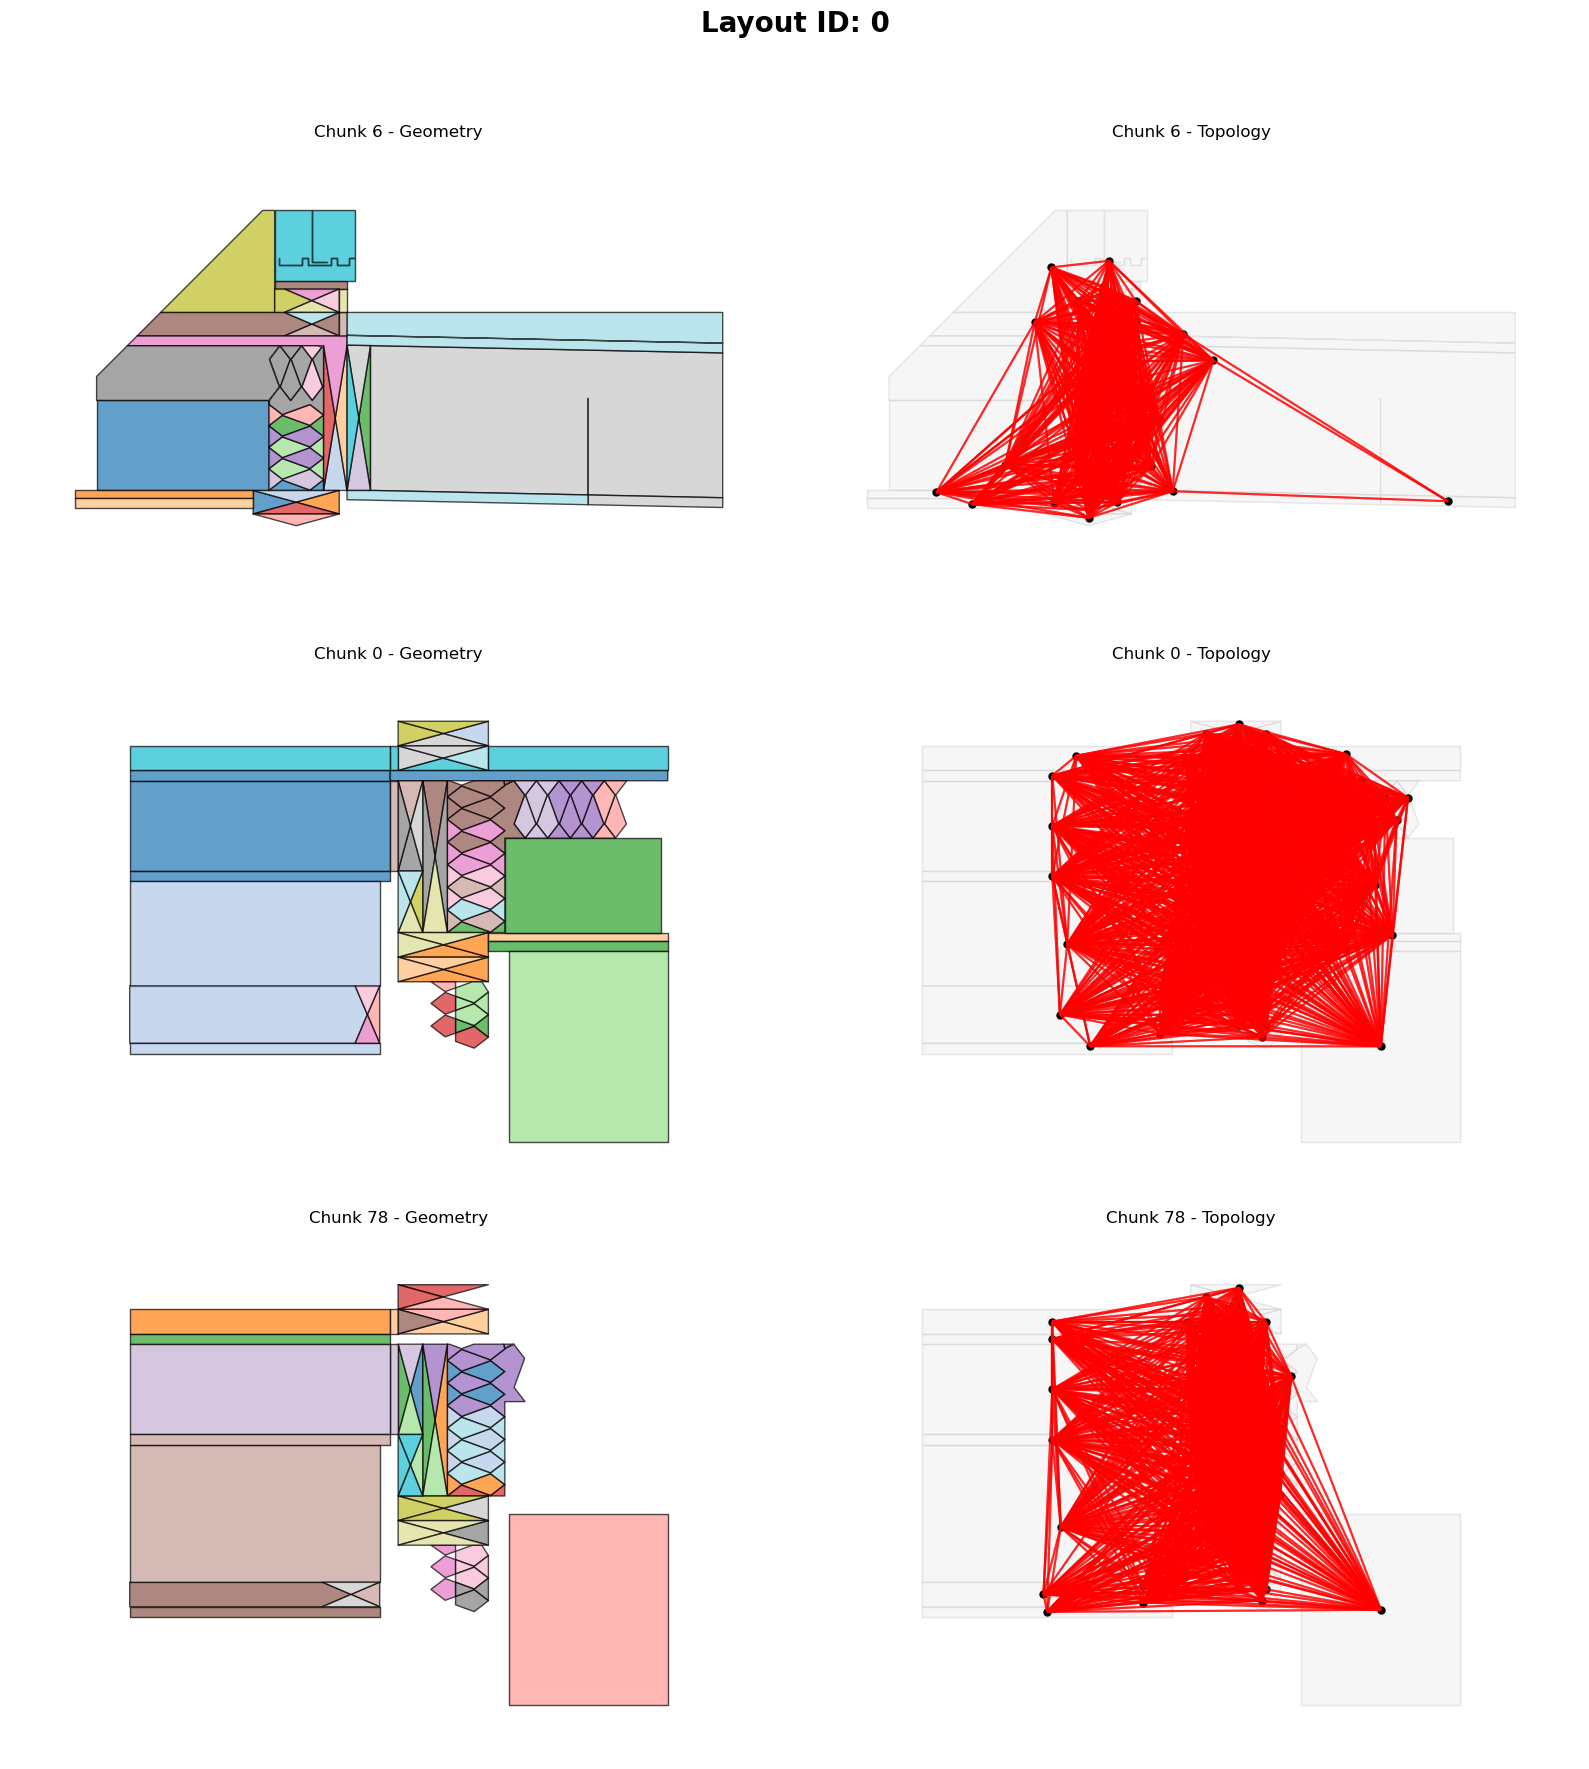


--- Visualizing Layout 1 (3 chunks) ---


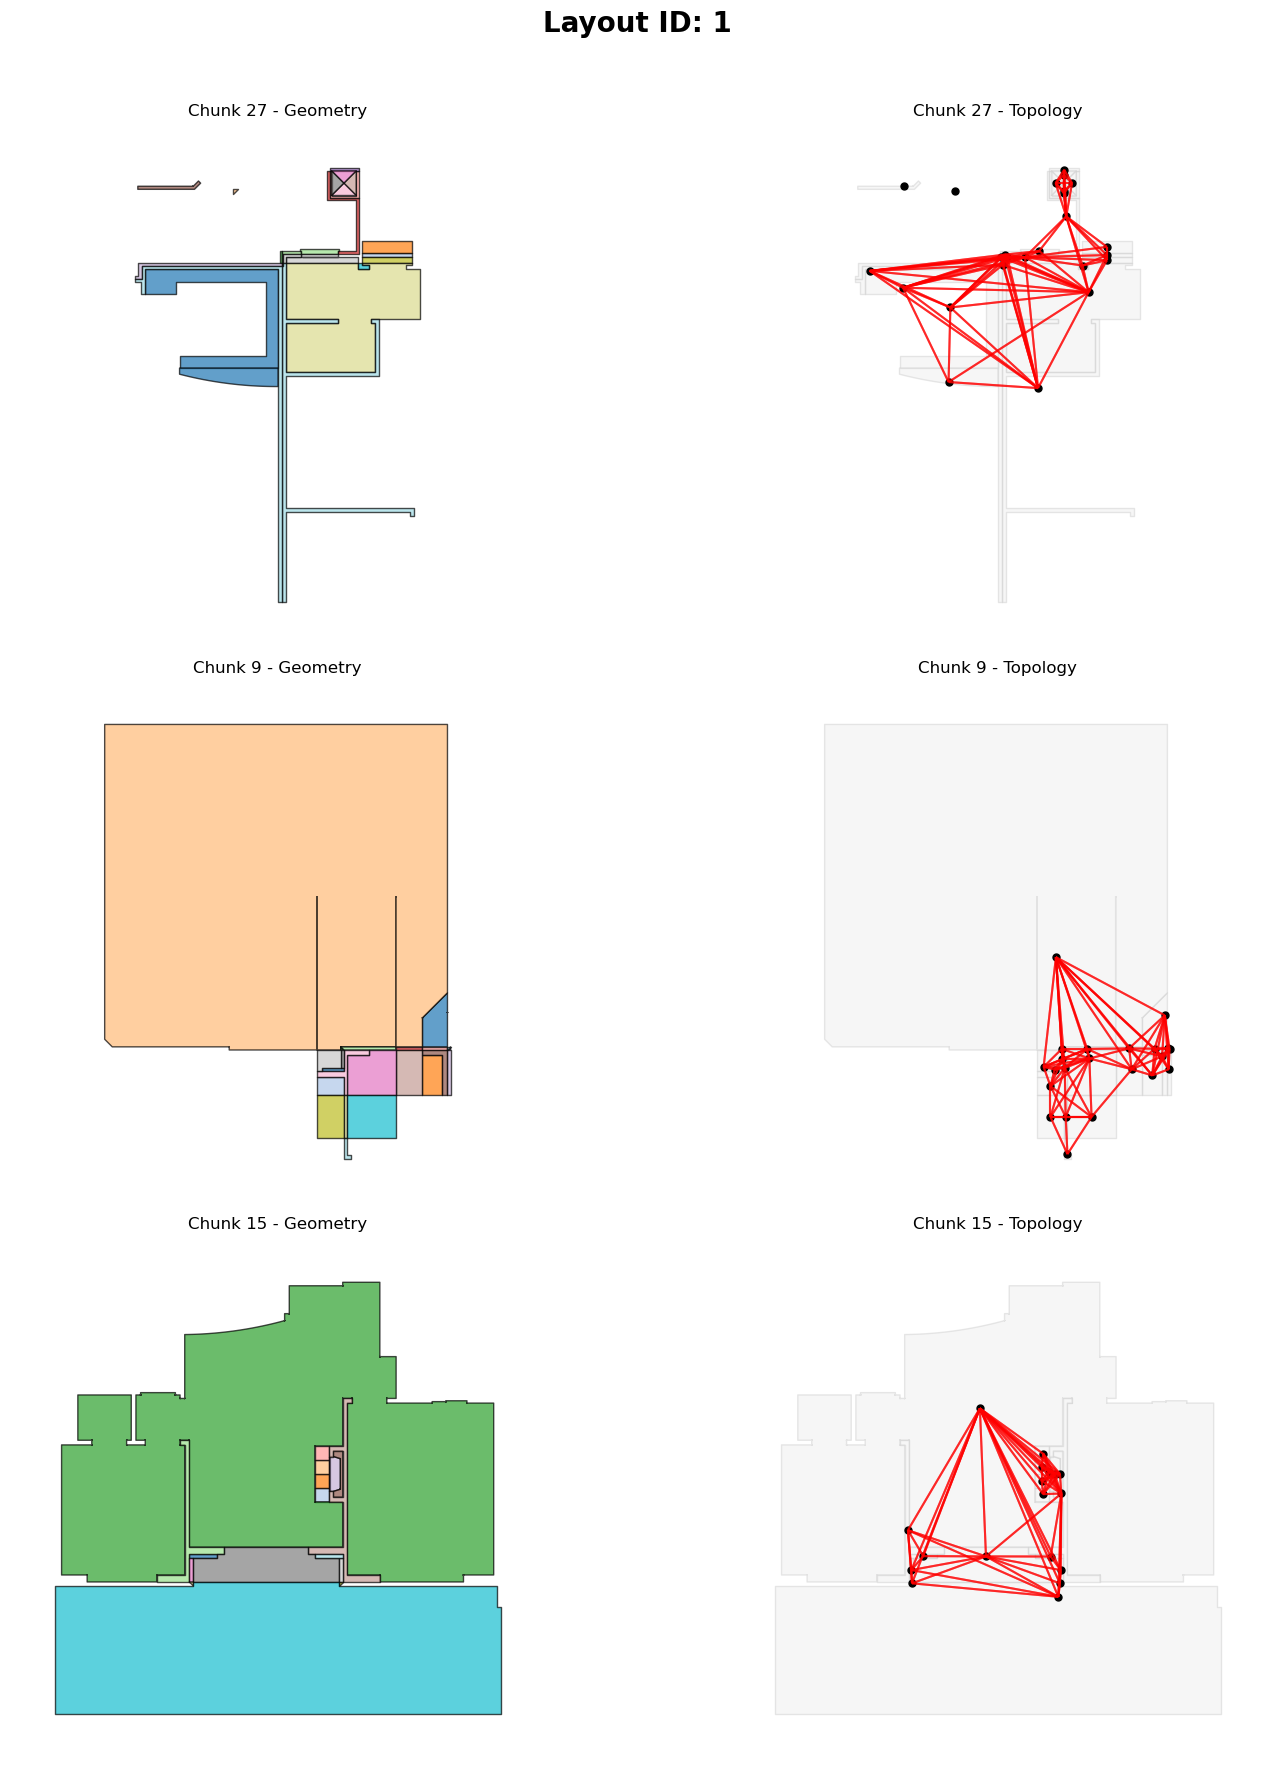

In [2]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection, LineCollection
from collections import defaultdict

# ==========================================
# 1. HELPER: GEOMETRY LOOKUP
# ==========================================
def build_geometry_lookup(geojson_path):
    """
    Creates a lookup: (layout_id, chunk_id) -> List of Polygon Coords
    Sorted by node_id.
    """
    print(f"[INFO] Indexing GeoJSON geometry from {geojson_path}...")
    
    grouped = {} 
    with open(geojson_path, 'r') as f:
        data = json.load(f)
        for feature in data['features']:
            props = feature['properties']
            lid = props['layout_id']
            cid = props['chunk_id']
            # Handle potential naming variations
            nid = props.get('node_id', props.get('chunk_node_id'))
            
            geom = feature['geometry']
            if geom and 'coordinates' in geom:
                key = (lid, cid)
                if key not in grouped: grouped[key] = []
                grouped[key].append((nid, geom['coordinates'][0]))
    
    # Sort by node_id and extract coords
    lookup = {}
    for key, items in grouped.items():
        items.sort(key=lambda x: x[0]) 
        lookup[key] = [item[1] for item in items]
    return lookup

def group_indices_by_layout(dataset):
    """
    Returns a dict: { layout_id: [dataset_index_1, dataset_index_2, ...] }
    """
    print("[INFO] Grouping dataset indices by Layout ID...")
    layout_map = defaultdict(list)
    for idx, data in enumerate(dataset):
        lid = data.layout_id.item() if torch.is_tensor(data.layout_id) else data.layout_id
        layout_map[lid].append(idx)
    return layout_map

# ==========================================
# 2. VISUALIZATION LOGIC
# ==========================================
def visualize_layouts(dataset, geojson_path, samples_per_layout=3):
    
    # 1. Prepare Data Maps
    geo_lookup = build_geometry_lookup(geojson_path)
    layout_indices = group_indices_by_layout(dataset)
    
    unique_layouts = sorted(layout_indices.keys())
    print(f"[INFO] Found {len(unique_layouts)} unique layouts: {unique_layouts}")

    # 2. Iterate over EACH Layout
    for lid in unique_layouts:
        available_indices = layout_indices[lid]
        
        # Determine how many to plot (don't crash if layout has fewer chunks than requested)
        n_samples = min(len(available_indices), samples_per_layout)
        
        # Pick random samples for this specific layout
        selected_indices = np.random.choice(available_indices, n_samples, replace=False)
        
        print(f"\n--- Visualizing Layout {lid} ({n_samples} chunks) ---")

        # Create a Figure for this Layout
        fig, axes = plt.subplots(n_samples, 2, figsize=(16, 6 * n_samples))
        if n_samples == 1: axes = [axes] # Handle single row case
        
        # Set Figure Title
        fig.suptitle(f"Layout ID: {lid}", fontsize=20, fontweight='bold', y=0.98)

        for row, idx in enumerate(selected_indices):
            data = dataset[idx]
            cid = data.chunk_id.item() if torch.is_tensor(data.chunk_id) else data.chunk_id
            
            # --- A. Retrieve & Process Geometry ---
            poly_coords_list = geo_lookup.get((lid, cid), [])
            
            polygons = []
            true_centroids = []
            all_coords = []
            
            for coords in poly_coords_list:
                all_coords.append(coords)
                polygons.append(MplPolygon(np.array(coords), closed=True))
                
                # Calculate Centroid
                pts = np.array(coords[:-1]) 
                if len(pts) > 0:
                    true_centroids.append(np.mean(pts, axis=0))
                else:
                    true_centroids.append([0,0])

            true_centroids = np.array(true_centroids)
            
            # --- B. Plot Left: Raw Geometry ---
            ax_geo = axes[row][0] if n_samples > 1 else axes[0]
            
            if polygons:
                # Color polygons distinctively
                colors = plt.cm.tab20(np.linspace(0, 1, len(polygons)))
                pc = PatchCollection(polygons, facecolor=colors, edgecolor='black', alpha=0.7)
                ax_geo.add_collection(pc)
                
                # Scaling
                all_pts = np.concatenate([np.array(p) for p in all_coords])
                min_x, min_y = all_pts.min(axis=0)
                max_x, max_y = all_pts.max(axis=0)
                pad = max(max_x-min_x, max_y-min_y) * 0.1
                ax_geo.set_xlim(min_x - pad, max_x + pad)
                ax_geo.set_ylim(min_y - pad, max_y + pad)
            
            ax_geo.set_title(f"Chunk {cid} - Geometry", fontsize=12)
            ax_geo.set_aspect('equal')
            ax_geo.axis('off')

            # --- C. Plot Right: Graph Overlay ---
            ax_graph = axes[row][1] if n_samples > 1 else axes[1]
            
            # 1. Draw Nodes
            if len(true_centroids) > 0:
                ax_graph.scatter(true_centroids[:, 0], true_centroids[:, 1], c='black', s=25, zorder=5)
                
                # 2. Draw Edges
                edge_index = data.edge_index.numpy()
                lines = []
                if edge_index.shape[1] > 0:
                    for e in range(edge_index.shape[1]):
                        u, v = edge_index[0, e], edge_index[1, e]
                        if u < len(true_centroids) and v < len(true_centroids):
                            lines.append([true_centroids[u], true_centroids[v]])
                
                if lines:
                    lc = LineCollection(lines, colors='red', linewidths=1.5, alpha=0.6, zorder=10)
                    ax_graph.add_collection(lc)

            # 3. Draw Ghost Background
            if polygons:
                pc_ghost = PatchCollection(polygons, facecolor='#eeeeee', edgecolor='#d0d0d0', alpha=0.5, zorder=0)
                ax_graph.add_collection(pc_ghost)

            # Sync Axis
            ax_graph.set_xlim(ax_geo.get_xlim())
            ax_graph.set_ylim(ax_geo.get_ylim())
            ax_graph.set_title(f"Chunk {cid} - Topology", fontsize=12)
            ax_graph.set_aspect('equal')
            ax_graph.axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust for suptitle
        plt.show()

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    GEOJSON_FILE = "chunked_data.geojson"
    ROOT_DIR = "./dataset_root"

    # 1. Load Dataset
    dataset = ArchitecturalGraphDataset(root=ROOT_DIR)
    
    # 2. Visualize per Layout
    # This will generate ONE window per Layout ID
    visualize_layouts(dataset, GEOJSON_FILE, samples_per_layout=3)

[INFO] Encoding dataset...
[FAISS] Indexed 238 vectors.
[UMAP] Projecting data to 2D...


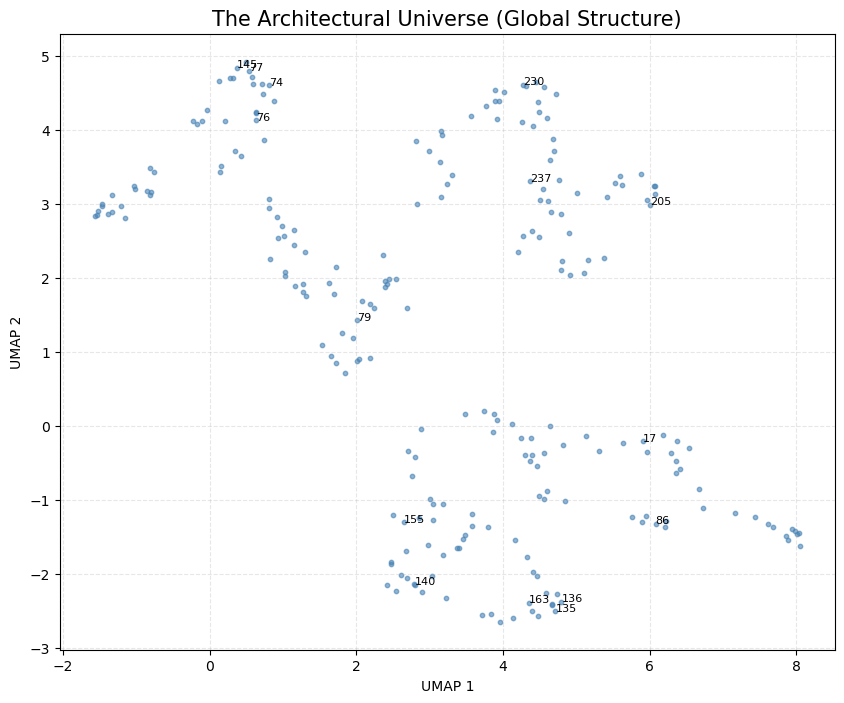


 SOTA SEARCH ENGINE READY



Target Index (0-237), 'r' random, 'q' quit:  2


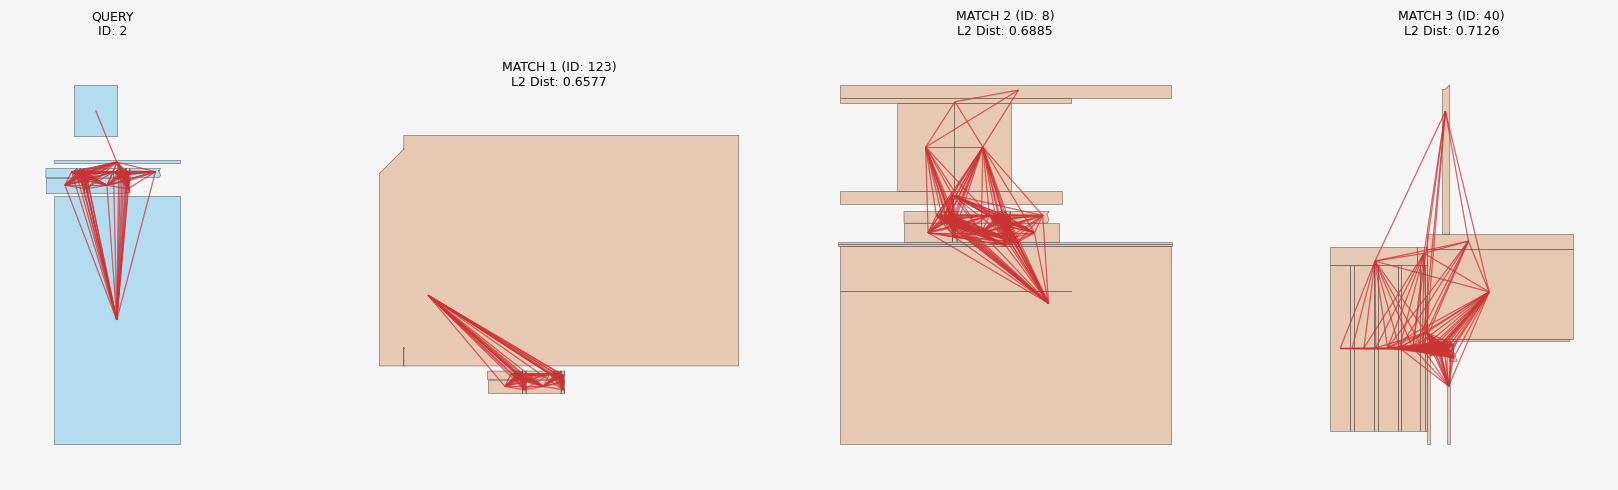


Target Index (0-237), 'r' random, 'q' quit:  200


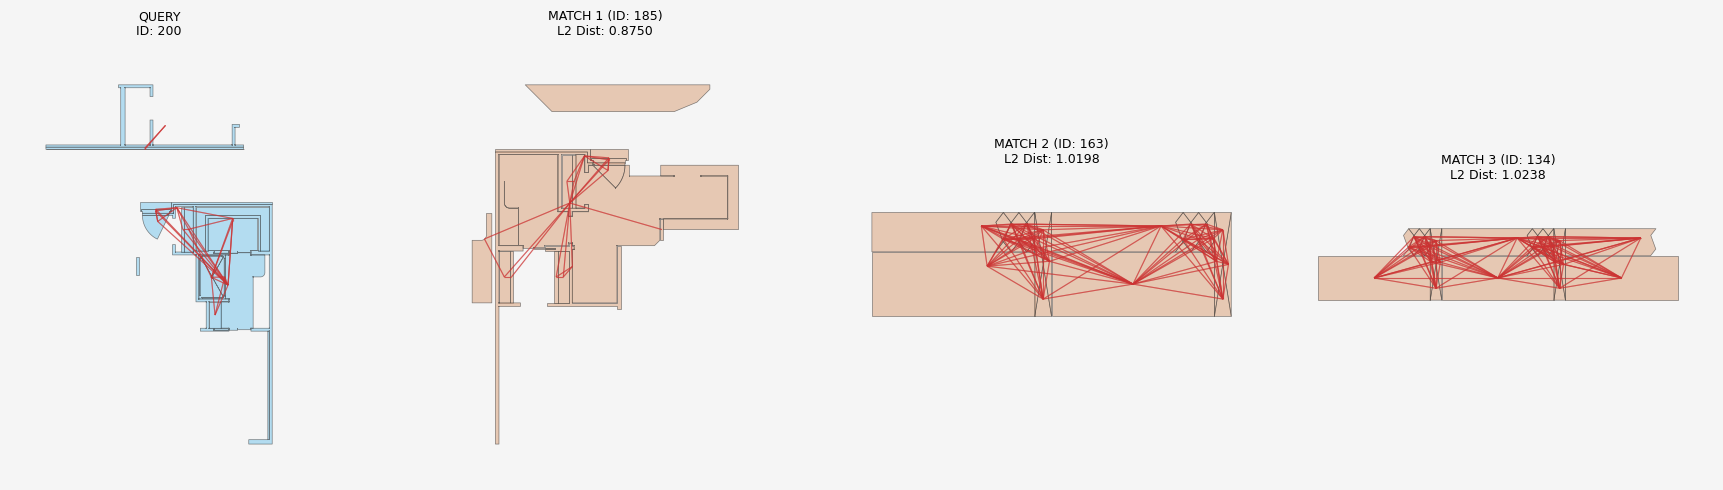

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_add_pool
from torch_geometric.loader import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection, LineCollection
import json
import os
import faiss  # <--- THE SPEED UPGRADE
import umap   # <--- THE GLOBAL VIEW

# ==========================================
# 1. MODEL DEFINITION (Must match training)
# ==========================================
class ArchitecturalEncoder(nn.Module):
    def __init__(self, in_channels, hidden_dim=256, embedding_dim=128, pe_dim=8):
        super().__init__()
        self.input_net = nn.Sequential(
            nn.Linear(in_channels + pe_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim), nn.ReLU()
        )
        self.conv1 = GINConv(self.make_mlp(hidden_dim))
        self.conv2 = GINConv(self.make_mlp(hidden_dim))
        self.conv3 = GINConv(self.make_mlp(hidden_dim))
        self.conv4 = GINConv(self.make_mlp(hidden_dim))
        self.proj_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, embedding_dim)
        )
        self.pe_dim = pe_dim

    def make_mlp(self, dim):
        return nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.ReLU(),
            nn.Linear(dim, dim), nn.ReLU()
        )

    def forward(self, x, edge_index, batch, pos_enc=None):
        if pos_enc is None:
            pos_enc = torch.zeros((x.size(0), self.pe_dim), device=x.device)
        x = torch.cat([x, pos_enc], dim=1)
        x = self.input_net(x)
        x = x + self.conv1(x, edge_index)
        x = x + self.conv2(x, edge_index)
        x = x + self.conv3(x, edge_index)
        x = x + self.conv4(x, edge_index)
        x = global_add_pool(x, batch)
        x = self.proj_head(x)
        x = F.normalize(x, p=2, dim=1)
        return x

# ==========================================
# 2. FAISS INDEXER (The 100x Speedup)
# ==========================================
class VectorDatabase:
    def __init__(self, embedding_dim=128):
        # We use IndexFlatL2 for exact Euclidean search.
        # For >100k vectors, you would switch to faiss.IndexHNSWFlat for O(log N) speed.
        self.index = faiss.IndexFlatL2(embedding_dim)
        self.vectors = None

    def add(self, vectors):
        # FAISS expects float32
        self.vectors = vectors.astype('float32')
        self.index.add(self.vectors)
        print(f"[FAISS] Indexed {self.index.ntotal} vectors.")

    def search(self, query_vec, k=5):
        """
        Returns (distances, indices)
        """
        query = query_vec.reshape(1, -1).astype('float32')
        # D = squared L2 distances, I = indices
        D, I = self.index.search(query, k)
        
        # Convert Squared L2 to Euclidean (Sqrt)
        return np.sqrt(D[0]), I[0]

# ==========================================
# 3. GLOBAL MAP (UMAP)
# ==========================================
def plot_global_structure(embeddings, labels=None):
    print("[UMAP] Projecting data to 2D...")
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean')
    embedding_2d = reducer.fit_transform(embeddings)
    
    plt.figure(figsize=(10, 8))
    plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c='steelblue', s=10, alpha=0.6)
    plt.title("The Architectural Universe (Global Structure)", fontsize=15)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.grid(True, linestyle='--', alpha=0.3)
    
    # Annotate a few random points
    indices = np.random.choice(len(embeddings), 15, replace=False)
    for i in indices:
        plt.text(embedding_2d[i, 0], embedding_2d[i, 1], str(i), fontsize=8)
        
    plt.show()

# ==========================================
# 4. CLEAN VISUALIZATION
# ==========================================
def render_chunk(ax, data, poly_coords_list, title, color_tint='skyblue'):
    # Geometry
    polygons = [MplPolygon(np.array(p), closed=True) for p in poly_coords_list]
    
    if polygons:
        # Combine all points to find bounds
        all_pts = np.concatenate([np.array(p) for p in poly_coords_list])
        min_x, min_y = all_pts.min(axis=0)
        max_x, max_y = all_pts.max(axis=0)
        
        # Dynamic Zoom
        width, height = max_x - min_x, max_y - min_y
        pad = max(width, height) * 0.1
        ax.set_xlim(min_x - pad, max_x + pad)
        ax.set_ylim(min_y - pad, max_y + pad)

        # Draw Polygons
        pc = PatchCollection(polygons, facecolor=color_tint, edgecolor='#333333', alpha=0.6, linewidth=0.5)
        ax.add_collection(pc)

    # Topology (Graph Edges)
    if data.edge_index.shape[1] > 0:
        # Calculate centroids on the fly
        centroids = []
        for p in poly_coords_list:
            pts = np.array(p[:-1])
            centroids.append(np.mean(pts, axis=0) if len(pts) > 0 else [0,0])
        
        centroids = np.array(centroids)
        edge_index = data.edge_index.numpy()
        
        lines = []
        for e in range(edge_index.shape[1]):
            u, v = edge_index[0, e], edge_index[1, e]
            if u < len(centroids) and v < len(centroids):
                lines.append([centroids[u], centroids[v]])
        
        lc = LineCollection(lines, colors='#cc3333', linewidths=0.8, alpha=0.5)
        ax.add_collection(lc)

    ax.set_title(title, fontsize=9, pad=10)
    ax.axis('off')
    ax.set_aspect('equal')

# ==========================================
# 5. DATA HELPERS
# ==========================================
def build_geometry_lookup(geojson_path):
    grouped = {} 
    with open(geojson_path, 'r') as f:
        data = json.load(f)
        for feature in data['features']:
            props = feature['properties']
            key = (props['layout_id'], props['chunk_id'])
            if key not in grouped: grouped[key] = []
            grouped[key].append((props.get('node_id'), feature['geometry']['coordinates'][0]))
    
    lookup = {}
    for key, items in grouped.items():
        items.sort(key=lambda x: x[0]) 
        lookup[key] = [item[1] for item in items]
    return lookup

def get_all_embeddings(dataset, model, device):
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    model.eval()
    vecs = []
    print("[INFO] Encoding dataset...")
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            emb = model(batch.x, batch.edge_index, batch.batch, batch.pos_enc)
            vecs.append(emb.cpu().numpy())
    return np.vstack(vecs)

# ==========================================
# MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    ROOT_DIR = "./dataset_root"
    GEOJSON = "chunked_data.geojson"
    MODEL_PATH = "trained_model_ultimate.pth"
    
    if not os.path.exists(MODEL_PATH):
        print("Model not found. Run training first.")
        exit()

    # 1. Init
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    dataset = ArchitecturalGraphDataset(root=ROOT_DIR)
    geo_lookup = build_geometry_lookup(GEOJSON)
    
    # 2. Load Model
    model = ArchitecturalEncoder(in_channels=dataset.num_features, pe_dim=8).to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    
    # 3. Create Vector DB
    embeddings = get_all_embeddings(dataset, model, device)
    
    # 4. Build FAISS Index (The Engine)
    db = VectorDatabase(embedding_dim=128)
    db.add(embeddings)
    
    # 5. Show Global Structure (The Map)
    # This window will pop up first. Close it to start searching.
    plot_global_structure(embeddings)
    
    # 6. Interactive Search
    print("\n" + "="*50)
    print(" SOTA SEARCH ENGINE READY")
    print("="*50)
    
    while True:
        try:
            inp = input(f"\nTarget Index (0-{len(dataset)-1}), 'r' random, 'q' quit: ")
            if inp.lower() == 'q': break
            query_idx = np.random.randint(0, len(dataset)) if inp.lower() == 'r' else int(inp)
            if query_idx >= len(dataset): continue
        except: continue
        
        # --- FAISS SEARCH ---
        # 0.00ms execution time
        distances, indices = db.search(embeddings[query_idx], k=4)
        
        # --- VISUALIZE ---
        fig, axes = plt.subplots(1, 4, figsize=(18, 5))
        fig.patch.set_facecolor('#f5f5f5')
        
        # Plot Query
        q_d = dataset[query_idx]
        q_id_tuple = (int(q_d.layout_id), int(q_d.chunk_id))
        render_chunk(axes[0], q_d, geo_lookup.get(q_id_tuple, []), 
                    f"QUERY\nID: {query_idx}", color_tint='#88ccee')
        
        # Plot Matches
        # indices[0] is the query itself (dist 0.0), so we look at 1, 2, 3
        matches = indices[1:]
        dists = distances[1:]
        
        for i, idx in enumerate(matches):
            r_d = dataset[idx]
            r_id_tuple = (int(r_d.layout_id), int(r_d.chunk_id))
            dist = dists[i]
            
            # Color code based on quality
            # <0.3 is usually exact, <0.6 is good, >1.0 is unrelated
            tint = '#aaddaa' if dist < 0.5 else '#ddaa88'
            
            render_chunk(axes[i+1], r_d, geo_lookup.get(r_id_tuple, []),
                        f"MATCH {i+1} (ID: {idx})\nL2 Dist: {dist:.4f}", color_tint=tint)
            
        plt.tight_layout()
        plt.show()